Aquí se encuentra el proyecto principal, antes que nada hay que comenzar a
importar las librerias necesarias.

In [2]:
#Nuestro equipo eligio como activo financiero al Paladio.
#Su clave en Yahoo Finance es "PA=F"
import yfinance as yf
import pandas as pd
import numpy as np
import Funciones_Creadas as fc
import scipy.stats
from scipy.stats import kurtosis, skew, shapiro, norm

# Proyecto 1 MCF (2026-02)
## Integrantes del equipo
    * Arriaga Nieto Naveed Zuriel
    * Lopez Martines Brauleo
    * Ramos Martines Angel Gabriel

### Actividades

1. Cargar y/o descargar datos de alguna fuente de informacion financiera del activo financiero de tu elección desde 2010 ( ́ındice accionario, precio de una acción, precio de una materia prima, (cripto)moneda, etc), en el reporte describe el activo que de tu elección

&nbsp;&nbsp;&nbsp;<u> Solución </u>

In [3]:
"""
Se nos pide descargar la información de Yahoo Finance, entonces haremos uso del
modulo creado en Funciones_Creadas
"""
import datetime as dt
from Funciones_Creadas import descargar_datos
#Recordemos que nuestro activo financiero es el Paladio ("PA=F")
activo = 'PA=F' #Nombre del Activo en Yahoo Finance
al_dia = dt.datetime.now()  #La fecha del día actual que se hace la evaluación
de_inicio = dt.datetime(2010,1,1) #El ejercicio nos dice que los datos tienen que ser desde el 2010
data=descargar_datos(activo,de_inicio,al_dia)
print(data)


[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker             PA=F         PA=F         PA=F         PA=F   PA=F
Date                                                                 
2010-01-04   419.799988   419.799988   419.799988   419.799988      0
2010-01-05   420.350006   420.350006   420.350006   420.350006      0
2010-01-06   425.600006   425.600006   425.600006   425.600006      0
2010-01-07   422.950012   422.950012   422.950012   422.950012      0
2010-01-08   424.149994   425.000000   425.000000   424.149994      1
...                 ...          ...          ...          ...    ...
2026-04-23  1484.599976  1484.599976  1484.599976  1484.599976      3
2026-04-24  1501.500000  1501.500000  1501.500000  1501.500000      1
2026-04-27  1477.699951  1477.699951  1477.699951  1477.699951      4
2026-04-28  1461.099976  1461.099976  1461.099976  1461.099976      4
2026-04-29  1466.500000  1466.500000  1466.500000  1466.500000      1

[4086 rows x 5 colu

2. Calcula los rendimientos diarios del activo financiero, reporta dentro del Streamlit la media, sesgo y exceso de curtosis. 

Ticker          PA=F
Date                
2010-01-05  0.001310
2010-01-06  0.012490
2010-01-07 -0.006226
2010-01-08  0.002837
2010-01-11  0.016032
...              ...
2026-04-23 -0.040398
2026-04-24  0.011384
2026-04-27 -0.015851
2026-04-28 -0.011234
2026-04-29  0.003696

[4085 rows x 1 columns]
El valor de la curtosis es de:
[9.13585464]
Los datos siguen una distribución leptucurtica, es decir, tiene una menor concentración en la mediana y tiene colas pesadas
El sesgo es de:
[-0.05225405]
Esto nos indica que la cola izquierda es más larga y más pesada que la derecha.


<Figure size 1200x500 with 0 Axes>

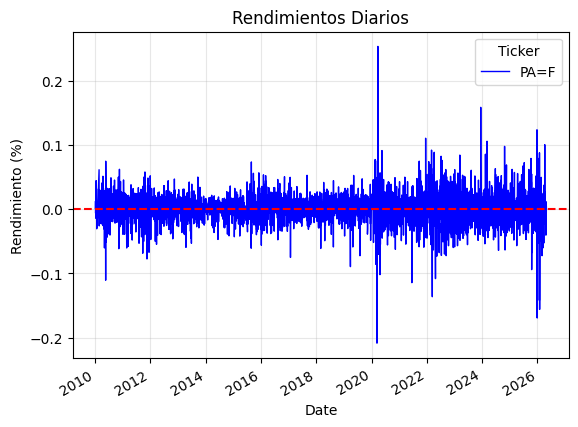

In [4]:
"""
Ahora, se nos pide calcular los rendimientos, el sesgo y la curtosis
"""
#Rendimiento 
from Funciones_Creadas import rendimientos
rendimientos_diarios = rendimientos(data)
print(rendimientos_diarios)

#Curtosis 
from Funciones_Creadas import curtosis
k= curtosis(rendimientos_diarios)
print(f"El valor de la curtosis es de:")
print(k)

#Vamos a hacer el analisis de la Curtosis
if k > 3:
    print("Los datos siguen una distribución leptucurtica, es decir, tiene una" 
          " menor concentración en la mediana y tiene colas pesadas")
if k < 3:
    print("Los datos siguen una distribución platicurtica, es decir, hay una"
          " mayor concentración en la mediana y tiene colas ligeras")
if k == 3:
    print("La distribución de los datos parece indicar una distribución normal")

#Sesgo
from Funciones_Creadas import sesgo
s = sesgo(rendimientos_diarios)
print("El sesgo es de:")
print(s)

#Analisis del Sesgo
if s > 0:
    print("Esto nos indica que la cola derecha es más larga y más pesada que "
          "la izquierda.")
if s < 0:
    print("Esto nos indica que la cola izquierda es más larga y más pesada que "
          "la derecha.")
if s == 0:
    print("Los datos no tienden a inclinarse ni a la derecha ni a la izquierda")

#Teniendo los datos anteriores, vamos a graficar los rendimientos.
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
rendimientos_diarios.plot(color='blue', linewidth=1)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Rendimientos Diarios')
plt.ylabel('Rendimiento (%)')
plt.grid(True, alpha=0.3)
plt.show()


3. Calcula el VaR y ES para la serie completa de datos a los siguientes intervalos de confianza: α = 0,95, 0,975, y 0,99 bajo una aproximación paramétrica asumiendo una distribución normal y t-student, además bajo una aproximación histórica y Monte Carlo. Muestra tus resultados en una tabla en el reporte.

In [ ]:
"""
Ahora hay que calcular el VaR (Value at Risk) y ES (Espected Shortfall) para los siguientes alpha's
α = 0.95
α = 0.975
α = 0.99
"""
from scipy import stats
from scipy.stats import t
from Funciones_Creadas import Value_at_Risk
from Funciones_Creadas import Expected_Shortfall
#Aproximación Parametrica
print("Aproximación Parametrica")

#Asumamos que primero se trata de una Distribución Normal
print("Value-at-Risk")
print("Distribución Normal")
mu, sigma = stats.norm.fit(rendimientos_diarios) #Esto para encontrar los parametros para la normal


#Al 95%
print("El Value at Risk al 95% asumiendo que los datos se"
      " distribuyen normal es de:")
print(stats.norm.ppf(0.05, mu, sigma)) #Ya es el cuantil

#Al 97.5%
print("El Value at Risk al 97.5% asumiendo que los datos se"
      " distribuyen normal es de:")
print(stats.norm.ppf(0.025, mu, sigma))

#Al 99%
print("El Value at Risk al 95% asumiendo que los datos se"
      " distribuyen normal es de:")
print(stats.norm.ppf(0.01, mu, sigma))


#%% Aquí ya es lo del Expected Shortfall
print("Expected Shortfall")
#Ahora calculemos el Expected Shortfall
#Antes voy a tener que crear una función que me ayude a calcular el Expected Shortfall

from Funciones_Creadas import Expected_Shortfall_normal

#ES 95%
print("El Expected Shortfall al 95% asumiendo que los datos se"
      " distribuyen normal es:")
print(Expected_Shortfall_normal(0.05, mu, sigma))

#ES 97.5%
print("El Expected Shortfall al 97.5% asumiendo que los datos se"
      " distribuyen normal es:")
print(Expected_Shortfall_normal(0.025, mu, sigma))

#ES 99%
print("El Expected Shortfall al 99% asumiendo que los datos se"
      " distribuyen normal es:")
print(Expected_Shortfall_normal(0.01, mu, sigma))

###################################################################################################################
from Funciones_Creadas import Expected_Shortfall_tstudent
print("-"*50)
#Ahora asumamos que se trata de una Distribución T-Student
print("Con distribución t-student")

#Primero vamos con el VaR
df, loc, scale = stats.t.fit(rendimientos_diarios)
#Al 95%
print("El Value at Risk al 95%  asumiendo que los datos se"
      " distribuyen t-student es de:")
print((stats.t.ppf(.05,df,loc,scale)))

#Al 97.5%
print("El Value at Risk al 97.5%  asumiendo que los datos se"
      " distribuyen t-student es de:")
print((stats.t.ppf(.025,df,loc,scale)))

#Al 99%
print("El Value at Risk al 95% asumiendo que los datos se"
      " distribuyen t-student es de:")
print((stats.t.ppf(.01,df,loc,scale)))

#Ahora vamos con el ES

#ES 95%
print("El Expected Shortfall usando la distribución t-student al 95% es de:")
E11 = Expected_Shortfall_tstudent(0.05, df, loc, scale)
print(E11)

#ES 97.5%
print("El Expected Shortfall usando la distribución t-student al 97.5% es de:")
E12 = Expected_Shortfall_tstudent(0.025, df, loc, scale)
print(E12)

#ES 99%
print("El Expected Shortfall usando la distribución t-student al 99% es de:")
E13 = Expected_Shortfall_tstudent(0.01, df, loc, scale)
print(E13)


Aproximación Parametrica
Value-at-Risk
Distribución Normal
El Value at Risk al 95% asumiendo que los datos se distribuyen normal es de:
-0.03782840173428842
El Value at Risk al 97.5% asumiendo que los datos se distribuyen normal es de:
-0.045186395485467906
El Value at Risk al 95% asumiendo que los datos se distribuyen normal es de:
-0.05374165336435809
Expected Shortfall
El Expected Shortfall al 95% asumiendo que los datos se distribuyen normal es:
-0.04758563492374131
El Expected Shortfall al 97.5% asumiendo que los datos se distribuyen normal es:
-0.05400913177062428
El Expected Shortfall al 99% asumiendo que los datos se distribuyen normal es:
-0.061654362034672276
--------------------------------------------------
Con distribución t-student
El Value at Risk al 95%  asumiendo que los datos se distribuyen t-student es de:
-0.034295814672111034
El Value at Risk al 97.5%  asumiendo que los datos se distribuyen t-student es de:
-0.044769916620658906
El Value at Risk al 95% asumiendo qu

In [ ]:
#Aproximación Historica
from Funciones_Creadas import Value_at_Risk
from Funciones_Creadas import Expected_Shortfall
#VaR
# VaR 95%
print("El VaR Historico al 95% es de:")
print(Value_at_Risk(rendimientos_diarios, .05))
# VaR 97.5%
print("El VaR Historico al 95% es de:")
print(Value_at_Risk(rendimientos_diarios, .025))
# VaR 99%
print("El VaR Historico al 95% es de:")
print(Value_at_Risk(rendimientos_diarios, .01))

#CVaR
#CVaR 95%
print("El CVaR Historico al 95% es de:")
print(Expected_Shortfall(rendimientos_diarios,.05))

#CVaR 97.5%
print("El CVaR Historico al 97.5% es de:")
print(Expected_Shortfall(rendimientos_diarios,.025))

#CVaR 99%
print("El CVaR Historico al 99% es de:")
print(Expected_Shortfall(rendimientos_diarios,.01))






El VaR Historico al 95% es de:
0.035342416590060405
El VaR Historico al 95% es de:
0.04579373356914265
El VaR Historico al 95% es de:
0.05938806282466617
El CVaR Historico al 95% es de:
Ticker
PA=F   -0.002167
dtype: float64
El CVaR Historico al 97.5% es de:
Ticker
PA=F   -0.001085
dtype: float64
El CVaR Historico al 99% es de:
Ticker
PA=F   -0.000282
dtype: float64


In [ ]:
#Ahora hagamos el metodo Monte Carlo

4. En el mercado, el VaR y el ES son las medidas populares para medir el riesgo de una cartera o un activo, sin embargo, es común ver que usan rolling windows, i.e. fijar una ventana de X d ́ıas y con esos datos calcular el VaR o ES del d ́ıa X + 1, ejemplo: con una ventana de 252 retornos (r1, r2, ..., r252) calculas el V aRα asociado al retorno 253, ahora el V aRα asociado al retorno 254 viene del conjunto de datos (r2, r3, ..., r253), etc. Con esto en mente en una sola gr ́afica muestra las ganancias y p ́erdidas además del VaR y el ES con α = 0,95 y 0,99 con una rolling window de 252 retornos (debe de ser una serie de tiempo) y sobre todo recuerda que el V aRt α es calculado con los retornos r1, r2, ..., r252 y busca predecir el retorno r253, y el V aRt+1. α calculado con los retornos r2, r3, ..., r253 busca predecir el retorno r254, etc.La estimación del VaR y ES debe de ser histórico y paramétrico (puedes asumir una distribución normal por practicidad), recuerda el ejemplo que se vio en clase.

5. Finalmente, para saber la eficiencia de nuestras estimaciones calcularemos el numero de veces que la perdida fue superior a la estimacion usando Var o ES, i.e. Definiremos violacion si r253 < V aRtα o EStα donde el V aRtα o EStα fue calculado con los retornos r1, r2, ..., r252, o si r254 < V aRt
α o EStα donde el V aRtα o EStα fue calculado con los retornos r2, r3, ..., r253, etc. En una tabla reporta el numero de violaciones y como porcentaje del tamaño de la muestra para cada nivel de confianza y cada medida de riesgo.

6. En esta pregunta se estimará el VaR con una volatilidad móvil y asumiendo una distribucion normal a traves de la siguiente formula: V aR1−α = qα × σ252t, donde qα es el percentil asociado a una distribucion normal con α como nivel de significancia y los siguientes valores α = 0,05 y α = 0,01, y σ252t, es la desviacion estandar de una ventana de 252 retornos.

    Utilizando la misma logica del rolling windows calcula el VaR para ambos niveles de significancia, grafica tus resultado como en la pregunta anterior y muestra la eficiencia de esta aproximacion calculando el numero de violaciones como en la pregunta anterior.